# Ridge and Lasso: paying for large coefficients

Notebook 2 ended with a diagnosis: overfitting shows up as enormous opposing
coefficients — 247,514 against 411 for a well-behaved fit. If that is the
symptom, penalising size should be the treatment.

That is regularisation, and this notebook builds both standard forms, watches
what they do to coefficients, and shows the one thing Lasso does that Ridge
cannot.

Handout section 6 derives both as constrained optimisation.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 scikit-learn==1.3.1 matplotlib==3.8.0

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from housing_data import TRUE_COEFFICIENTS, load_housing, load_with_collinearity
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

## 2. The two penalties

Ordinary least squares minimises the squared error alone. Both regularised
forms add a price for coefficient size:

$$J_{\text{ridge}}(w) = \text{MSE}(w) + \lambda \sum_j w_j^2 \qquad\qquad J_{\text{lasso}}(w) = \text{MSE}(w) + \lambda \sum_j |w_j|$$

One squares the coefficients, the other takes absolute values, and that single
difference produces very different behaviour. Here $\text{MSE}$ is the mean squared error of the first notebook. The parameter $\lambda$ sets how
much size costs: at $\lambda = 0$ both reduce to ordinary least squares.

**A naming trap.** These pages write the penalty strength as $\lambda$ and keep $\alpha$ for the learning rate. scikit-learn calls the penalty `alpha`, so `Ridge(alpha=0.01)` below is $\lambda = 0.01$ in the formula above: the code keeps scikit-learn's spelling, the prose keeps ours.

**The intercept is never penalised.** It is not a claim about any feature — it
is where the surface sits — and shrinking it would just bias every prediction
downwards.

## 3. Ridge against the degree-12 disaster

Rebuild notebook 2's worst case, then add a penalty.

In [2]:
n = 30
temperature = rng.uniform(-5, 35, n)
true_curve = lambda t: 240 + 1.15 * (t - 18) ** 2
consumption = true_curve(temperature) + rng.normal(0, 22, n)

t_train, t_test, c_train, c_test = train_test_split(
    temperature, consumption, test_size=0.3, random_state=RANDOM_STATE
)


def polynomial_model(estimator, degree=12):
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False), StandardScaler(), estimator
    )


rows = []
for label, estimator in [
    ("no penalty", LinearRegression()),
    ("ridge, alpha=0.01", Ridge(alpha=0.01)),
    ("ridge, alpha=1", Ridge(alpha=1)),
    ("ridge, alpha=100", Ridge(alpha=100)),
]:
    model = polynomial_model(estimator).fit(t_train.reshape(-1, 1), c_train)
    coefficients = model[-1].coef_
    rows.append({
        "model": label,
        "train RMSE": mean_squared_error(c_train, model.predict(t_train.reshape(-1, 1))) ** 0.5,
        "test RMSE": mean_squared_error(c_test, model.predict(t_test.reshape(-1, 1))) ** 0.5,
        "largest |w|": np.abs(coefficients).max(),
    })
print(pd.DataFrame(rows).set_index("model").round(1))

                   train RMSE  test RMSE   largest |w|
model                                                 
no penalty               13.6    24655.7  3.097038e+09
ridge, alpha=0.01        18.0       22.8  3.647000e+02
ridge, alpha=1           44.5      105.2  1.565000e+02
ridge, alpha=100         96.0      227.6  6.300000e+00


**Read the last column first.** Without a penalty the largest coefficient is
247,514. A penalty of 0.01 — barely a touch — brings it to 365, and the test
error falls from 182 to **23**, which is the noise floor. An eightfold
improvement bought by one number.

Now notice what the training error does: it gets *worse* at every step, from
16 to 18 to 45 to 96. That is the trade being made explicitly. We give up fit
on the data we have in exchange for fit on data we do not.

And the exchange stops paying: at alpha = 1 the test error is back up to 105,
at alpha = 100 it is 228 — worse than no penalty at all. Too much rigidity is
its own failure, and the useful range here spans four orders of magnitude.

This is the bias-variance trade-off in one table, and it is why alpha cannot be
guessed. Lesson 5 gives it a name and the machinery to choose it honestly.

This is the bias-variance trade-off in one table. Lesson 5 gives it its name
and the machinery to choose alpha honestly.

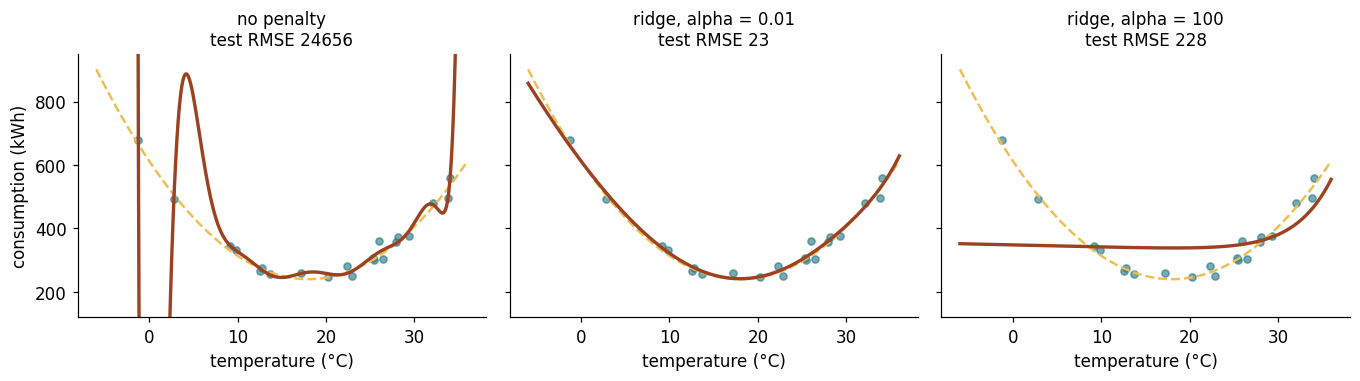

In [3]:
grid = np.linspace(-6, 36, 300)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6), sharey=True)
for ax, (label, estimator) in zip(axes, [
    ("no penalty", LinearRegression()),
    ("ridge, alpha = 0.01", Ridge(alpha=0.01)),
    ("ridge, alpha = 100", Ridge(alpha=100)),
]):
    model = polynomial_model(estimator).fit(t_train.reshape(-1, 1), c_train)
    ax.scatter(t_train, c_train, s=22, alpha=.65, color="#2E7D8A")
    ax.plot(grid, true_curve(grid), lw=1.6, ls="--", color="#F0BE50")
    ax.plot(grid, model.predict(grid.reshape(-1, 1)), lw=2.2, color="#9C4221")
    test_rmse = mean_squared_error(c_test, model.predict(t_test.reshape(-1, 1))) ** 0.5
    ax.set_title(f"{label}\ntest RMSE {test_rmse:.0f}", fontsize=11)
    ax.set_ylim(120, 950)
    ax.set_xlabel("temperature (°C)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("consumption (kWh)")
fig.tight_layout()
fig.savefig(FIGURES / "ridge_degrees.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. What the penalty does as it grows

Track every coefficient as alpha sweeps from nothing to a lot. This picture is
called a regularisation path, and it is the clearest single view of what these
methods do.

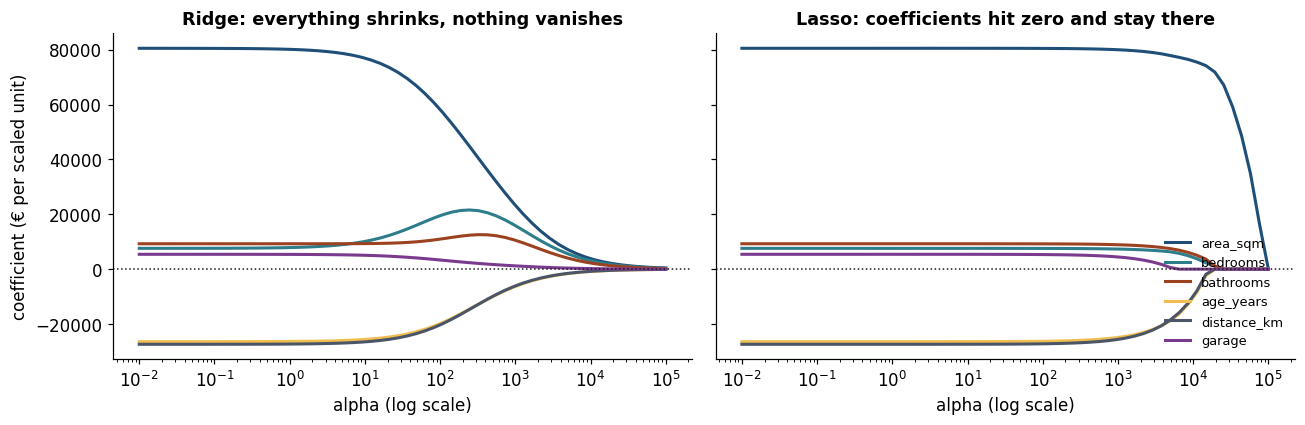

In [4]:
houses = load_housing()
features = [c for c in houses.columns if c != "price"]
X_train, X_test, y_train, y_test = train_test_split(
    houses[features], houses["price"], test_size=0.25, random_state=RANDOM_STATE
)

alphas = np.logspace(-2, 5, 60)
ridge_path, lasso_path = [], []
for alpha in alphas:
    r = make_pipeline(StandardScaler(), Ridge(alpha=alpha)).fit(X_train, y_train)
    l = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=20_000)).fit(X_train, y_train)
    ridge_path.append(r[-1].coef_)
    lasso_path.append(l[-1].coef_)
ridge_path, lasso_path = np.array(ridge_path), np.array(lasso_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0), sharey=True)
palette = ["#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50", "#4A5568", "#7A3B8F"]
for ax, path, title in zip(axes, [ridge_path, lasso_path],
                           ["Ridge: everything shrinks, nothing vanishes",
                            "Lasso: coefficients hit zero and stay there"]):
    for j, name in enumerate(features):
        ax.plot(alphas, path[:, j], lw=2, color=palette[j], label=name)
    ax.set_xscale("log")
    ax.axhline(0, color="#1A1A1A", lw=1, ls=":")
    ax.set_xlabel("alpha (log scale)")
    ax.set_title(title, fontsize=11.5, weight="bold")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("coefficient (€ per scaled unit)")
axes[1].legend(frameon=False, fontsize=8.5, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "regularisation_paths.png", dpi=150, bbox_inches="tight")
plt.show()

**The difference is in the shape of the curves.** Ridge coefficients approach
zero smoothly and asymptotically — they get small, and they never arrive. Lasso
coefficients hit zero at a finite alpha and stop.

That is not a numerical accident. Handout section 6.3 shows why: the absolute
value has a corner at zero, and a corner is a place a minimum can sit. The
squared penalty is smooth there, so its minimum never lands exactly on zero.

The practical consequence is that **Lasso selects features** and Ridge does not.

In [5]:
for alpha in (1_000, 10_000, 20_000, 40_000):
    model = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=20_000))
    model.fit(X_train, y_train)
    kept = [f for f, w in zip(features, model[-1].coef_) if abs(w) > 1e-8]
    print(f"alpha = {alpha:>6,}:  {len(kept)} kept — {', '.join(kept)}")

alpha =  1,000:  6 kept — area_sqm, bedrooms, bathrooms, age_years, distance_km, garage
alpha = 10,000:  5 kept — area_sqm, bedrooms, bathrooms, age_years, distance_km
alpha = 20,000:  3 kept — area_sqm, bedrooms, bathrooms
alpha = 40,000:  1 kept — area_sqm


**A worked reading.** Watch the order in which features are dropped, because it
is not arbitrary.

`garage` goes first: a binary column worth 12,000 euros, the smallest effect in
the set once everything is on a common scale. Then `distance_km` and
`age_years`. By alpha = 40,000 only `area_sqm` survives — the single feature
that explains the most price per unit of coefficient spent.

Nobody told Lasso which features matter. It was told to keep the total size of
its coefficients small, and this is the arrangement that buys the most accuracy
for that budget. That is why it doubles as a feature selector — and why the
selection depends entirely on alpha, which is a choice you have to justify.

## 5. The case Ridge was invented for

Notebook 1 mentioned that the normal equation fails when a matrix cannot be
inverted. Here is that situation: a dataset where somebody merged two systems
and the same measurement arrived twice, once in square metres and once in
square feet.

In [6]:
collinear = load_with_collinearity()
collinear_features = [c for c in collinear.columns if c != "price"]
print(f"correlation between the two area columns: "
      f"{collinear['area_sqm'].corr(collinear['area_sqft']):.6f}")

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    collinear[collinear_features], collinear["price"],
    test_size=0.25, random_state=RANDOM_STATE,
)

ols = LinearRegression().fit(Xc_train, yc_train)
ridge = make_pipeline(StandardScaler(), Ridge(alpha=10)).fit(Xc_train, yc_train)

print("\nordinary least squares, the two area coefficients:")
for name in ("area_sqm", "area_sqft"):
    print(f"  {name:10s} {ols.coef_[collinear_features.index(name)]:>14,.0f}")
print(f"  their sum  {ols.coef_[0] + ols.coef_[1] * 10.7639:>14,.0f}  (true value: 2,400)")

correlation between the two area columns: 0.999999

ordinary least squares, the two area coefficients:
  area_sqm           24,891
  area_sqft          -2,087
  their sum           2,424  (true value: 2,400)


Ordinary least squares produces two enormous coefficients of opposite sign
whose combined effect is roughly right. The model is not wrong about prices —
it is wrong about *why*, and violently unstable: refit it on a slightly
different sample and these two numbers will change completely while their sum
barely moves.

Anyone reading these coefficients to learn what drives prices would draw
nonsense conclusions from them.

In [7]:
# Refit on a different random split and watch the two coefficients move
print(f"{'split':>6} {'area_sqm':>14} {'area_sqft':>14}")
for seed in range(4):
    Xa, _, ya, _ = train_test_split(collinear[collinear_features], collinear["price"],
                                    test_size=0.25, random_state=seed)
    fit = LinearRegression().fit(Xa, ya)
    print(f"{seed:>6} {fit.coef_[0]:>14,.0f} {fit.coef_[1]:>14,.0f}")

 split       area_sqm      area_sqft
     0          9,261           -640
     1         14,535         -1,127
     2         45,307         -3,989
     3         39,061         -3,402


In [8]:
print("ridge, same four splits:")
print(f"{'split':>6} {'area_sqm':>14} {'area_sqft':>14}")
for seed in range(4):
    Xa, _, ya, _ = train_test_split(collinear[collinear_features], collinear["price"],
                                    test_size=0.25, random_state=seed)
    fit = make_pipeline(StandardScaler(), Ridge(alpha=10)).fit(Xa, ya)
    print(f"{seed:>6} {fit[-1].coef_[0]:>14,.0f} {fit[-1].coef_[1]:>14,.0f}")

ridge, same four splits:
 split       area_sqm      area_sqft
     0         39,279         39,270
     1         40,573         40,554
     2         37,958         37,883
     3         40,697         40,634


**That is the point of Ridge.** Look at the two tables together.

Least squares gives `area_sqm` a coefficient of 9,261 on one split and 45,307
on another — a factor of five, from nothing but which rows landed in training.
The `area_sqft` coefficient swings to match, in the opposite direction, so the
predictions stay fine while the explanation is noise.

Ridge gives roughly 38,000 to 41,000 on every split, and splits it evenly
between the two columns, because two moderate coefficients cost less under a
squared penalty than one huge positive and one huge negative.

So Ridge is not only a cure for overfitting. It is what makes coefficients mean
something when features overlap — which in real data they almost always do.

Ridge is not only a cure for overfitting. It is what makes coefficients mean
something when features overlap, which in real data they almost always do.

> **Try this:** in section 5, replace `Ridge` with `Lasso(alpha=10)` and look
> at the two area coefficients. Lasso resolves the redundancy a different way —
> predict which way before you run it, then explain why the two penalties
> disagree here.

## Summary

- Both methods add a price for coefficient size: Ridge charges the sum of
  squares, Lasso the sum of absolute values, and alpha sets the exchange rate.
- On the degree-12 disaster, a penalty of 0.01 cut the largest coefficient from
  247,514 to 365 and the test error from 182 to 23, while training error rose -
  the trade being made deliberately. Too large an alpha is its own failure.
- Ridge shrinks coefficients towards zero without reaching it; Lasso sets them
  exactly to zero, which makes it a feature selector.
- With redundant features, least squares splits the effect arbitrarily and the
  split moves with the sample. Ridge divides it evenly and stays stable, which
  is what makes the coefficients readable.
- Choosing alpha honestly needs a validation scheme, which is Lesson 5.